# Import Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using OrdinaryDiffEq
Random.seed!(145975);
using KernelDensity
using LaTeXStrings
using StatsBase
using JLD2
using HypothesisTests
using LaTeXStrings
using Trapz
using DataFrames, GLM, StatsBase


In [2]:
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\BayesianInference\\FunctionsBayesInfs.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\InitalParameterFitPriorDef\\ModelFunctionsAll.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ComputationalBayesianOED\\FunctionsBayesOED.jl")

redSamples (generic function with 2 methods)

# Distribution Examples

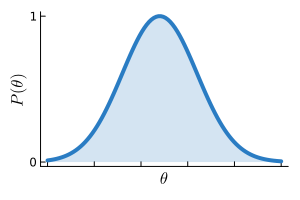

In [3]:
Prior = Normal(7,4)

x = range(-5,20, length=100)
y = pdf.(Prior, x)

ppt = plot(x,y./maximum(y), label = "", grid = false, xlabel = L"\theta", ylabel = L"P(\theta)", linewidth = 4, fillrange = zeros(length(y)), fillalpha = 0.2,
        size=(300,200), xformatter=_->"", yticks =[0,1], colour="#287ac2fc")


savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\PriorDistribution.svg")

display(ppt)

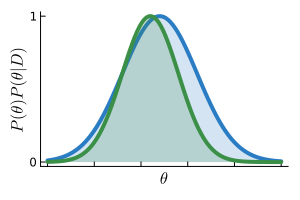

In [4]:
Prior = Normal(7,4)
Post1 = Normal(6,3)

x = range(-5,20, length=100)
y = pdf.(Prior, x)

x2 = range(-5,20, length=100)
y2 = pdf.(Post1, x2)

ppt = plot(x,y./maximum(y), label = "", grid = false, xlabel = L"\theta", ylabel = L"P(\theta) P(\theta | D)", linewidth = 4, fillrange = zeros(length(y)), fillalpha = 0.2,
        size=(300,200), xformatter=_->"", yticks =[0,1], colour="#287ac2fc")

plot!(x2,y2./maximum(y2), label = "", fillrange = zeros(length(y)), linewidth = 4, fillalpha = 0.2, colour="#3a8f46fc")

savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\BadPosteriorDistribution.svg")

display(ppt)

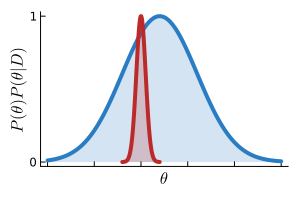

In [5]:
Prior = Normal(7,4)
Post1 = Normal(5,0.5)

x = range(-5,20, length=100)
y = pdf.(Prior, x)

x2 = range(3,7, length=100)
y2 = pdf.(Post1, x2)

ppt = plot(x,y./maximum(y), label = "", grid = false, xlabel = L"\theta", ylabel = L"P(\theta) P(\theta | D)", linewidth = 4, fillrange = zeros(length(y)), fillalpha = 0.2,
        size=(300,200), xformatter=_->"", yticks =[0,1], colour="#287ac2fc")

plot!(x2,y2./maximum(y2), label = "", fillrange = zeros(length(y)), linewidth = 4, fillalpha = 0.2, colour="#bb2929fc")


savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\GoodPosteriorDistribution.svg")

display(ppt)

# Simulate and Plot Example Experiments

In [6]:
function simDwnExp(expS, datsD, PyrCons, nSamps, poster, allD, plt = false)
    tsC2 = vcat(collect(0:5:395));
    ts = 0:tsC2[end];
    samps = convert.(Int, tsC2);


    exin = findall(expS .== datsD)
    postDwn = poster[StatsBase.sample(1:size(poster)[1], nSamps, replace = false),:]

    scF = allD[exin][1][1,2]/(PyrCons[1]*1000*0.12)

    simsPrior = Array{Any}(undef, nSamps);
    for i in 1:nSamps
        ivss = [round(PyrCons[1], digits = 1)*1000, 0, 0, postDwn[i,14], postDwn[i,15], postDwn[i,16], 0, 0, 0, 0, 0, round(PyrCons[1], digits = 1)*1000, 0, round(PyrCons[1], digits = 1)*1000*(scF*0.12)];;
        samps = convert.(Int, tsC2);

        SimulsAll, SimulsAll2, SimulsAll3 = PyruvateHP_NMR_SolveAllCp(ts, vcat(postDwn[i,1:12], scF, 0), ivss, samps);
        simsPrior[i] = SimulsAll;
    end


    # Dims = Up/Down, Observable, Experiment
    PriorQuant = Array{Any}(undef,2,1,1);
    lacPirorSims = zeros(size(simsPrior[1])[1], nSamps)
    [lacPirorSims[:,i] = simsPrior[i][:,13,1] for i in 1:nSamps ];
    for k in 1:1
        for m in 1:1
            PriorQuant[1,k,m] = [percentile(lacPirorSims[j,:], 99.5) for j in 1:size(lacPirorSims)[1]]; # Up
            PriorQuant[2,k,m] = [percentile(lacPirorSims[j,:], 0.5 ) for j in 1:size(lacPirorSims)[1]]; # Down
        end
    end

    if plt == true
        pr = scatter(allD[exin][1][:,1]./60, allD[exin][1][:,4], yerror = allD[exin][1][:,5], label = "")
        plot!(tsC2./60, PriorQuant[1], label = "", color = "red", linewidth = 3,
            margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
            xlabel = "time (min)", ylabel = "Lactate (AU)")
        plot!(tsC2./60, PriorQuant[2], label = "", color = "red", linewidth = 3)
        plot!(tsC2./60, PriorQuant[1], fillrange=PriorQuant[2], label="", color="red", fillalpha=0.2)

        display(pr)
    end

    return(simsPrior, PriorQuant)

end

simDwnExp (generic function with 2 methods)

In [7]:
poster1 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_Init_Try1.csv", DataFrame));

posterR2 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_Ran1c_Try1c.csv", DataFrame));
posterI2 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_ID1_Try1.csv", DataFrame));
posterO2 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_OED1_Try1.csv", DataFrame));

posterR3 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_Ran2d_Try1.csv", DataFrame));
posterI3 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_ID2b_Try1.csv", DataFrame));
posterO3 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_OED2_Try1.csv", DataFrame));

posterR3b = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_Ran2g_Try1.csv", DataFrame));
posterO3b = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_OED2b_Try1.csv", DataFrame));

posterO4 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_OED3_Try2.csv",DataFrame));

posterO5 = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_FINAL\\Results\\PosteriorCompetitiveRepressionExp_OED3_Try2.csv",DataFrame));

In [8]:
mainD = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\";
# datsD = ["3Mil_0-0mMPyr_Dat","3Mil_0-6mMPyr_Dat","3Mil_0-8mMPyr_Dat","3Mil_1-6mMPyr_Dat","3Mil_3-2mMPyr_Dat", "3Mil_4-9mMPyr_Dat","3Mil_6-0mMPyr_Dat","3Mil_6-4mMPyr_Dat","3Mil_8-3mMPyr_Dat","3Mil_12-8mMPyr_Dat","3Mil_13-1mMPyr_Dat","3Mil_18-0mMPyr_Dat","3Mil_25-6mMPyr_Dat","3Mil_29-6mMPyr_Dat","3Mil_40-0mMPyr_Dat"]

datsD = ["3Mil_0-0mMPyr_Dat","3Mil_0-6mMPyr_Dat","3Mil_0-8mMPyr_Dat","3Mil_1-6mMPyr_Dat","3Mil_3-2mMPyr_Dat", "3Mil_6-0mMPyr_Dat","3Mil_6-4mMPyr_Dat","3Mil_8-3mMPyr_Dat","3Mil_12-8mMPyr_Dat","3Mil_13-1mMPyr_Dat","3Mil_18-0mMPyr_Dat","3Mil_25-6mMPyr_Dat","3Mil_29-6mMPyr_Dat","3Mil_40-0mMPyr_Dat"]

allD = [Matrix(CSV.read(mainD*datsD[i]*".csv", DataFrame)) for i in 1:length(datsD)];

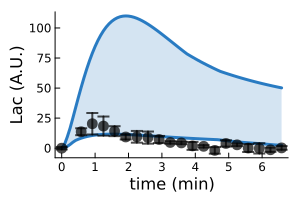

In [9]:
Random.seed!(78956321)

expSA = "3Mil_0-6mMPyr_Dat"
PyrConsA = [0.6]
# expSA = "3Mil_4-9mMPyr_Dat"
# PyrConsA = [4.9]
nSamps = 100#100

simsPrior, PriorQuant = simDwnExp(expSA, datsD, PyrConsA, nSamps, poster1, allD, false);


tsC2 = vcat(collect(0:5:395));
ts = 0:tsC2[end];
samps = convert.(Int, tsC2);
indD1 = findfirst(datsD .== expSA)

PPTS1 = plot(tsC2./60, PriorQuant[1], label = "", color = "#287ac2fc", linewidth = 3,
    # margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
    xlabel = "time (min)", ylabel = "Lac (A.U.)", grid = false, title = "",
    size=(300,200))

plot!(tsC2./60, PriorQuant[2], label = "", color = "#287ac2fc", linewidth = 3)
plot!(tsC2./60, PriorQuant[1], fillrange=PriorQuant[2], label="", color="#287ac2fc", fillalpha=0.2)


scatter!(allD[indD1][1:4:end,1]./60, allD[indD1][1:4:end,4], yerror = allD[indD1][1:4:end,5], label = "", colour = "black", linewidth=2, markersize=6, alpha=0.7)


savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\PriorPrediction.svg")


display(PPTS1)

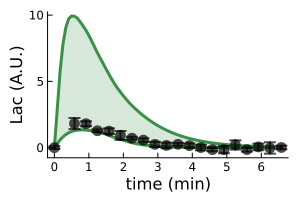

In [14]:
Random.seed!(78956321)

expSA = "3Mil_40-0mMPyr_Dat"
PyrConsA = [40]
# expSA = "3Mil_4-9mMPyr_Dat"
# PyrConsA = [4.9]
nSamps = 100#100

simsPosterBad, PriorPosterBad = simDwnExp(expSA, datsD, PyrConsA, nSamps, poster1, allD, false);


tsC2 = vcat(collect(0:5:395));
ts = 0:tsC2[end];
samps = convert.(Int, tsC2);
indD1 = findfirst(datsD .== expSA)

PPTS1 = plot(tsC2./60, PriorPosterBad[1]./10, label = "", color = "#3a8f46fc", linewidth = 3,
    # margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
    xlabel = "time (min)", ylabel = "Lac (A.U.)", grid = false, 
    size=(300,200))

plot!(tsC2./60, PriorPosterBad[2]./10, label = "", color = "#3a8f46fc", linewidth = 3)
plot!(tsC2./60, PriorPosterBad[1]./10, fillrange=PriorPosterBad[2]./10, label="", color="#3a8f46fc", fillalpha=0.2)


scatter!(allD[indD1][1:4:end,1]./60, allD[indD1][1:4:end,4]./10, yerror = allD[indD1][1:4:end,5]./10, label = "", colour = "black", linewidth=2, markersize=6, alpha=0.7, 
yticks =[0,5,10])


savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\BadPosteriorPrediction.svg")


display(PPTS1)

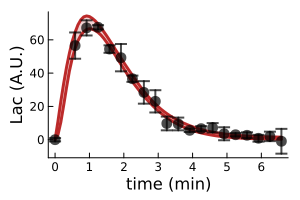

In [99]:
Random.seed!(78956321)

expSA = "3Mil_3-2mMPyr_Dat"
PyrConsA = [3.2]
# expSA = "3Mil_4-9mMPyr_Dat"
# PyrConsA = [4.9]
nSamps = 100#100

simsPosterGood, PosterGoodQuant = simDwnExp(expSA, datsD, PyrConsA, nSamps, poster1, allD, false);


tsC2 = vcat(collect(0:5:395));
ts = 0:tsC2[end];
samps = convert.(Int, tsC2);
indD1 = findfirst(datsD .== expSA)

PPTS1 = plot(tsC2./60, PosterGoodQuant[1], label = "", color = "#bb2929fc", linewidth = 3,
    # margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
    xlabel = "time (min)", ylabel = "Lac (A.U.)", grid = false, 
    size=(300,200))

plot!(tsC2./60, PosterGoodQuant[2], label = "", color = "#bb2929fc", linewidth = 3)
plot!(tsC2./60, PosterGoodQuant[1], fillrange=PosterGoodQuant[2], label="", color="#bb2929fc", fillalpha=0.2)


scatter!(allD[indD1][1:4:end,1]./60, allD[indD1][1:4:end,4], yerror = allD[indD1][1:4:end,5], label = "", colour = "black", linewidth=2, markersize=6, alpha=0.7)


savefig("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure1Stuff\\GoodPosteriorPrediction.svg")


display(PPTS1)